In [53]:
import pandas as pd
from IPython.display import display
import dataframe_image as dfi
import chromedriver_autoinstaller

# Auto-download and set up ChromeDriver
chromedriver_autoinstaller.install()


def get_IR_ID_SR_table(
    csv_path="produced_data_large_corpus/inter_intra_comparison.csv",
    languages=['DEU', 'ENG', 'FRA'],
    unit_types=['phones', 'sylls', 'words'],
    n_values=[1, 2, 3, 4],
    metrics=["IR", "ID", "SR"],
    text_types=['within_words', 'across_sentences']
):
    # Load CSV
    df = pd.read_csv(csv_path, encoding="utf-8")
    df.columns = df.columns.str.strip()

    # Filter languages
    df = df[df["Language"].isin(languages)]

    # Melt into long format
    df_long = df.melt(
        id_vars=["Speaker", "Language", "Text"],
        var_name="MetricType",
        value_name="Value"
    )

    # Extract components from MetricType
    metric_split = df_long["MetricType"].str.extract(
        r'(?P<TextType>within_words|across_sentences)_(?P<UnitType>phones|sylls|words)_(?P<Metric>ID|IR|SR)_(?P<N>unigram|bigram|trigram|quadgram)'
    )
    df_long = pd.concat([df_long.drop(columns=["MetricType"]), metric_split], axis=1)

    # Map n-gram labels to integers
    df_long["n"] = df_long["N"].map({
        "unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4
    })
    df_long = df_long.drop(columns="N")

    # Filter by selections
    df_long = df_long[
        (df_long["Language"].isin(languages)) &
        (df_long["UnitType"].isin(unit_types)) &
        (df_long["n"].isin(n_values)) &
        (df_long["Metric"].isin(metrics)) &
        (df_long["TextType"].isin(text_types))
    ]

    # Reorder for clarity
    df_long = df_long[["Language", "Speaker", "Text", "TextType", "UnitType", "Metric", "n", "Value"]]


    # Pivot with MultiIndex columns: TextType, Metric, n
    table = df_long.pivot_table(
        values="Value",
        index=["Language", "UnitType"],
        columns=["TextType", "Metric", "n"],
        aggfunc="mean"
    )

    #  Normalize the color gradient globally across the whole table
    vmin = df_long["Value"].min()
    vmax = df_long["Value"].max()

    # Display styled table
    display(
        table.style
        .set_table_styles(
            [{'selector': 'th', 'props': [('text-align', 'center')]}]
        )
        .set_properties(**{'text-align': 'center'})
        .background_gradient(cmap="Blues", vmin=vmin, vmax=vmax)
        .format("{:.2f}")
    )

    # Save styled table as PNG
    styled_table = (
        table.style
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
        .set_properties(**{'text-align': 'center'})
        .background_gradient(cmap="Blues", vmin=vmin, vmax=vmax)
        .format("{:.2f}")
    )
    # Save image 
    dfi.export(styled_table, f"images/table_{languages}_{unit_types}_{n_values}_{metrics}_{text_types}.png", table_conversion='matplotlib')


get_IR_ID_SR_table(
    csv_path="produced_data_large_corpus/inter_intra_comparison.csv",
    languages=['DEU', 'ENG', 'FRA'],
    unit_types=['sylls', 'phones'],
    n_values=[1,2],
    metrics=["IR"],
    text_types=['within_words', 'across_sentences']
)




Phones


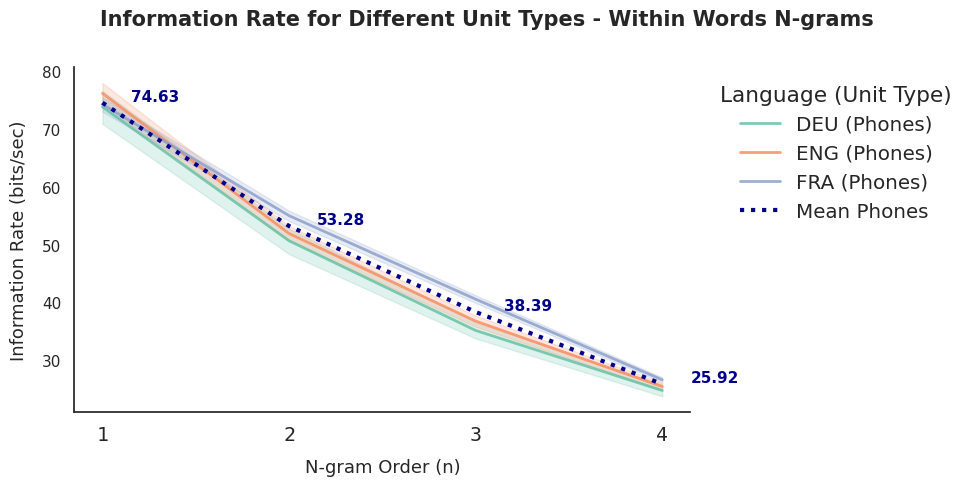

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import check_expected_values

def plot_inforate_vs_ngram_order(text_type, processing_types,languages):
    """
    Plot Information Rate vs. N-gram Order for different languages and linguistic units.
    Both syllables and phones appear as different lines in the same plot.
    
    Parameters:
    text_type (str): Either "within_words" or "across_sentences"
    """
    
    # Load and filter
    df = pd.read_csv(
        "produced_data_large_corpus/inter_intra_comparison.csv",
        encoding="utf-8",
        sep=","
    )
    
    df.columns = df.columns.str.strip()
    df = df[df["Language"].isin(languages)]
        
    # Check for data coverage 
    #if not check_expected_values(df):
        #print("Data coverage check failed. Ensure all expected values are present.")
        #return
    
    # Set style
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(10, 5))
    
    # Collect all data for both processing types
    all_data = []
    
    # Specify processing types
    for processing_type in processing_types: 
        
        # Find IR columns for this processing type and text type
        IR_cols = [col for col in df.columns 
                   if col.startswith(text_type) 
                   and processing_type in col 
                   and "IR_" in col]
    
        
        if not IR_cols:
            print(f"No IR columns found for {processing_type} and {text_type}")
            continue
            
        # Prepare data
        df_IR = df[["Language"] + IR_cols].copy()
        df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")
        
        # Extract n-gram order
        df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
        ngram_order = {"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4}
        df_IR_long["n"] = df_IR_long["n"].map(ngram_order)
        
        # Remove rows where n-gram order extraction failed
        df_IR_long = df_IR_long.dropna(subset=['n'])
        
        if df_IR_long.empty:
            print(f"No valid data for {processing_type}")
            continue
        
        # Add linguistic unit information
        unit_name = processing_type.title()
        print(unit_name)
        df_IR_long["Linguistic_Unit"] = unit_name
        
        # Create combined language-unit identifier for plotting
        df_IR_long["Language_Unit"] = df_IR_long["Language"] + " (" + df_IR_long["Linguistic_Unit"] + ")"
        
        all_data.append(df_IR_long)
    
    # Combine all data
    if not all_data:
        print("No valid data found for any processing type")
        return
    
    df_combined = pd.concat(all_data, ignore_index=True)
    
    # Alphabetical order of legend entries
    df_combined = df_combined.sort_values(by=["Language_Unit", "n"])
    ordered_labels = df_combined["Language_Unit"].drop_duplicates().tolist()
        
    # Create color palette - different colors for languages, different styles for units
    languages_units = df_combined["Language_Unit"].unique()
    custom_palette = sns.color_palette("Set2", n_colors=len(languages_units))
    
    # Plot all lines
    sns.lineplot(
        data=df_combined,
        x="n", y="IR",
        hue="Language_Unit", hue_order=ordered_labels,
        palette=custom_palette,
        linewidth=2, alpha=0.85, linestyle="-"
    )
    
    # Add mean lines for each linguistic unit
    for processing_type in processing_types:
        unit_name = processing_type.title()
        df_unit = df_combined[df_combined["Linguistic_Unit"] == unit_name]
        if not df_unit.empty:
            df_mean = df_unit.groupby("n", as_index=False)["IR"].mean()

            color = "darkred" if unit_name == "Sylls" else "darkblue"
            linestyle = "--" if unit_name == "Sylls" else ":"

            sns.lineplot(data=df_mean, x="n", y="IR", color=color, 
                        label=f"Mean {unit_name}", linewidth=3, linestyle=linestyle)

            for _, row in df_mean.iterrows():
                plt.text(
                    row["n"] + 0.28,    
                    row["IR"] + 0.28,       
                    f"{row['IR']:.2f}",
                    ha='center',
                    fontsize=11,
                    fontweight='bold',
                    color=color
                )
    
    # Customize plot
    label = text_type.replace('_', ' ').title()
    plt.suptitle(
        f"Information Rate for Different Unit Types - {label} N-grams",
        fontsize=15, weight='bold', y=0.98, ha='center'
    )
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", loc='center', fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit Type)", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(f"images/IR_vs_ngram_order_{text_type}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()


plot_inforate_vs_ngram_order(text_type = "within_words", processing_types = ['phones'], languages = ['DEU', 'ENG', 'FRA']) # Change as needed


Processing types: ['phones']


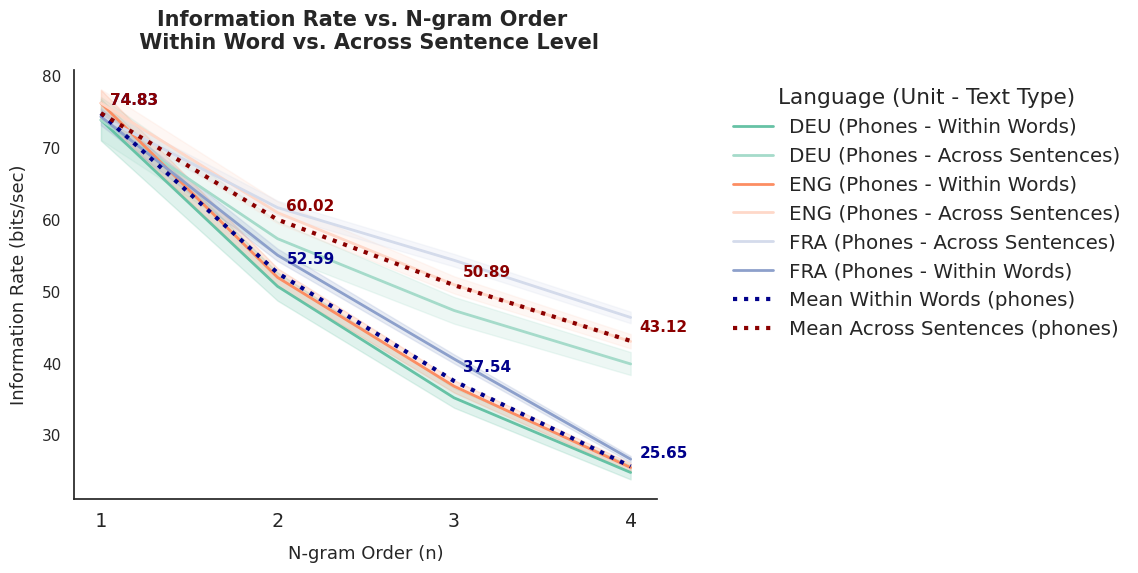

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import check_expected_values
from matplotlib.colors import to_rgba


def plot_inforate_combined_texttypes(languages, processing_types):
    """
    Plot Information Rate vs. N-gram Order for both words and sentences in a single plot.
    Each line = unique combination of language, processing type, and text level.
    Adds mean line for each processing type + text level.
    """

    # Load and filter data
    df = pd.read_csv("produced_data_large_corpus/inter_intra_comparison.csv", encoding="utf-8", sep=",")
    df.columns = df.columns.str.strip()
    df = df[df["Language"].isin(languages)]


    # Check for data coverage 
    #if not check_expected_values(df):
        #print("Data coverage check failed. Ensure all expected values are present.")
        #return


    all_data = []

    print(f"\nProcessing types: {processing_types}")
    for text_type in ["within_words", "across_sentences"]:
        for processing_type in processing_types:
            IR_cols = [col for col in df.columns if col.startswith(text_type) and processing_type in col and "IR_" in col]
            if not IR_cols:
                continue
            df_IR = df[["Language"] + IR_cols].copy()
            df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")
            df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
            df_IR_long["n"] = df_IR_long["n"].map({"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4})
            df_IR_long = df_IR_long.dropna(subset=["n"])
            df_IR_long["Linguistic_Unit"] = processing_type.title()
            df_IR_long["Text_Level"] = text_type 
            df_IR_long["Label"] = df_IR_long["Language"] + " (" + df_IR_long["Linguistic_Unit"] + " - " + text_type.replace('_', ' ').title() + ")"
            all_data.append(df_IR_long)

    if not all_data:
        print("No valid data found.")
        return

    df_combined = pd.concat(all_data, ignore_index=True)

    # Generate ordered labels for legend
    df_combined = df_combined.sort_values(by="Language")
    ordered_labels = df_combined["Label"].drop_duplicates().tolist()

    # Generate as many base colors as needed
    set2 = sns.color_palette("Set2", n_colors=12)

    # Get list of languages
    unique_languages = sorted(df_combined["Language"].unique())

    # Assign unique Set2 colors to languages
    language_to_base_color = dict(zip(unique_languages, set2[:len(unique_languages)]))

    def lighten_or_darken_color(color, factor=0.85):
        import matplotlib.colors as mc
        import colorsys
        """Lighten (factor > 1) or darken (factor < 1) an RGB color."""
        try:
            c = mc.cnames[color]
        except:
            c = color
        h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
        new_rgb = colorsys.hls_to_rgb(h, max(0, min(1, l * factor)), s)
        return new_rgb

    label_to_color = {}
    for lang in unique_languages:
        base = language_to_base_color[lang]
        for unit in df_combined["Linguistic_Unit"].unique():
            for text_level in ['within_words', 'across_sentences']:
                label = f"{lang} ({unit} - {text_level.replace('_', ' ').title()})"
                # Use original base color for within_words, modified version for across_sentences
                color = base if text_level == "within_words" else lighten_or_darken_color(base, factor=1.3)
                label_to_color[label] = color



    # Style and figure setup
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(12, 6))


    # Plot individual lines as solid lines
    sns.lineplot(
        data=df_combined, x="n", y="IR", hue="Label",
        hue_order=ordered_labels,
        palette=label_to_color,
        linewidth=2, alpha=1.0, linestyle="-"
    )

    # Add mean lines per processing type and text level
    mean_keys = []

    for processing_type in processing_types:
        for text_level in ['within_words', 'across_sentences']:
            key = (processing_type.title(), text_level)
            mean_keys.append(key)

    for processing_type in processing_types:
        unit_name = processing_type.title()
        for text_level in ['within_words', 'across_sentences']:
            level_name = text_level
            df_unit = df_combined[
                (df_combined["Linguistic_Unit"] == unit_name) &
                (df_combined["Text_Level"] == level_name)
            ]
            if not df_unit.empty:
                df_mean = df_unit.groupby(["Language", "n"], as_index=False)["IR"].mean()
                df_mean = df_mean.groupby("n", as_index=False)["IR"].mean()
  
                # Set distinct color + style per type
                level_name = text_level.replace('_', ' ').title()
                key = (unit_name, text_level)
                color = "darkblue" if level_name == "Within Words" else "darkred"
                linestyle = "--" if unit_name == "Sylls" else ":"

                sns.lineplot(data=df_mean, x="n", y="IR", color=color,
                             label=f"Mean {level_name} ({processing_type})", linewidth=3, linestyle=linestyle)

                x_offset = 0.05
                y_offset = (df_combined["IR"].max() - df_combined["IR"].min()) * 0.015

                for _, row in df_mean.iterrows():
                    plt.text(row["n"] + x_offset, row["IR"] + y_offset, f"{row['IR']:.2f}",
                        color=color, fontsize=11, fontweight='bold')

    # Customize plot
    plt.title("Information Rate vs. N-gram Order \n Within Word vs. Across Sentence Level",
              fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit - Text Type)", bbox_to_anchor=(1.1, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()

    # Save and show
    plt.savefig("images/IR_vs_ngram_order_within_words_across_sentences.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_inforate_combined_texttypes(languages=["FRA", "DEU", "ENG"], processing_types=["phones"])


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def IR_histogram(IR_type):
    """
    Function to plot histograms of Information Rate (IR) across languages.
    """ 

    # Load data
    df_IR = pd.read_csv(
        "C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/produced_data/ling_unit_comparison.csv",
        encoding="utf-8",
        sep=","
    )

    # Clean column names
    df_IR.columns = df_IR.columns.str.strip()

    assert IR_type in df_IR.columns, f"{IR_type} not found in df_IR columns"

    # Filter for selected languages
    languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
    df_IR = df_IR[df_IR["Language"].isin(languages)]

    # Map language families
    df_IR["Family"] = df_IR["Language"].map({
        "FRA": "Indo-European",
        "JPN": "Japanese",
        "CMN": "Sino-Tibetan",
        "VIE": "Austroasiatic",
        "YUE": "Sino-Tibetan",
        "ENG": "Indo-European",
        "DEU": "Indo-European"
    })

    # Prepare tidy data
    df_sn = df_IR[["Language", "Family", IR_type]].dropna()
    df_sn = df_sn.rename(columns={IR_type: "Value"})


    # add alpha column (e.g., for plotting transparency)
    df_sn["alpha"] = 0.1

    xlim_dict = {
        "IR_unigram_esidaine": (15, 75),
        "IR_bigram_esidaine": (0, 35),
        "IR_trigram_esidaine": (0, 15),
        "IR_quadgram_esidaine": (0, 8)
    }
    xlim = xlim_dict.get(IR_type, (10, 65))  

    ngram_label = IR_type.split("_")[1] + "s"

    # Prepare the data
    df_sn = df_IR[df_IR['Language'] != 'All']
    df_sn = df_sn.melt(id_vars=['Language', 'Family'], 
                    value_vars=[IR_type], 
                    var_name='Metric', value_name='Value')
    df_sn = df_sn[df_sn['Metric'] == IR_type].dropna()

    # Add aggregated "All" row
    all_data = df_sn.copy()
    all_data["Language"] = "All"
    all_data["Family"] = "All"
    df_sn = pd.concat([df_sn, all_data], axis=0, ignore_index=True)

    # Ensure all levels are retained by making Language categorical AFTER concat
    ordered_languages = ["All", "CMN", "YUE", "VIE", "ENG", "DEU", "FRA", "JPN"]
    df_sn["Language"] = pd.Categorical(df_sn["Language"], categories=ordered_languages, ordered=True)

    # Setup seaborn
    sns.set(style="white", font_scale=1.1)

    # Create color palette by Family
    unique_families = df_sn['Family'].dropna().unique()

    custom_palette = sns.color_palette("Set2", n_colors=len(unique_families))
    palette_dict = {fam: color for fam, color in zip(unique_families, custom_palette)}
    palette_dict["All"] = "#A9A9A9"   # Dark grey color for "All"
    df_sn["Color"] = df_sn["Family"].map(palette_dict)

    # Plot
    g = sns.FacetGrid(df_sn, row="Language", hue="Family", aspect=5, height=0.8, 
                    palette=palette_dict, margin_titles=True)

    # KDE per language
    def kde_with_outline(data, color, **kwargs):
        # Draw thick black outline first
        sns.kdeplot(data=data, x="Value", fill=True, color="black", alpha=1.0,
                    linewidth=3.0, **kwargs)
        # Then overlay the colored KDE
        sns.kdeplot(data=data, x="Value", fill=True, color=color, alpha=0.9,
                    linewidth=1.2, **kwargs)

    g.map_dataframe(kde_with_outline)

    # Draw KDE boundaries and mean
    def draw_one_vertical_line_in_each_axis(global_mean):
        for i, ax in enumerate(g.axes.flat):
            # Only draw in the leftmost axis (row "All")
            if i == 0:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
                ax.text(global_mean + 0.3, 0.55, "Mean",
                        transform=ax.get_xaxis_transform(),
                        fontsize=10, color='black', weight='light',
                        ha='left', va='bottom')
            else:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
    # Set dynamic xlim for all axes
    for ax in g.axes.flat:
        ax.set_xlim(*xlim)

    global_mean = df_IR[df_IR['Language'] != 'All'][IR_type].mean()
    print(f"Global mean for {IR_type}: {global_mean:.6f}")
    draw_one_vertical_line_in_each_axis(global_mean)

    g.set_titles(row_template="{row_name}", col_template="", size=10)

    # Remove vertical facet labels (the default row labels)
    for ax in g.axes[:, 0]:  # Only need to do this for one column
        if hasattr(ax, 'get_ylabel'):
            ax.set_ylabel("")

    for ax, label in zip(g.axes.flat, df_sn['Language'].cat.categories):
        ax.text(-0.05, 0.1, label, transform=ax.transAxes,
                fontsize= 9 , va='center', ha='right', rotation=0)

        
    # Remove default right-side facet titles
    g.set_titles(row_template="")  # Removes default titles

    # Hide all y-ticks and labels
    for ax in g.axes.flat:
        ax.set_ylabel("")
        ax.set_yticks([])

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)


    xtick_vals = list(range(xlim[0], xlim[1] + 1, 5))
    g.set(yticks=[], ylabel="")
    g.set(xticks=xtick_vals, xlabel="")
    g.set_xticklabels([str(x) for x in xtick_vals], fontsize=11)
    g.despine(left=True, bottom=False)
    plt.subplots_adjust(hspace=0.5, left=0.1, right=0.85)
    plt.suptitle(f"Information Rate (bits/sec) for {ngram_label}", fontsize=11, fontweight='bold', y=0.95)

    # Create a square-based legend with border
    legend_handles = [
        mpatches.Patch(color=palette_dict[f], label=f) for f in palette_dict
    ]
    legend = g.fig.legend(
        handles=legend_handles,
        title="Family",
        loc='center right',
        bbox_to_anchor=(1.3, 0.5),
        frameon=False, 
        edgecolor='black', 
        fontsize = '10'
    )
    g.fig.set_size_inches(4, 5) 

    # Add rectangle around the figure area
    g.figure.patches.append(Rectangle(
        (0.1, 0.11), 0.75, 0.774,  # (x,y), width, height in figure coordinates
        linewidth=0.8, edgecolor='black', facecolor='none',
        transform=g.figure.transFigure, clip_on=False
    ))
    plt.savefig(f"C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/images/IR_across_Languages_{ngram_label}.png", dpi=300, bbox_inches='tight')
    plt.show()

IR_histogram("IR_bigram_esidaine")